In [ ]:
import pandas as pd
import numpy as np
import joblib
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

print("Iniciando Pipeline de MLOps...")

# ==========================================
# 1. PREPARAÇÃO DOS DADOS NORMAIS (CLASSE 0)
# ==========================================
try:
    df_norm1 = pd.read_csv('logs-insights-results (1).csv', on_bad_lines='skip')
    df_norm2 = pd.read_csv('Sensor 1 e 4 sem vazamentos.csv', on_bad_lines='skip')
    df_normal = pd.concat([df_norm1, df_norm2], ignore_index=True)

    # Limpeza e Filtro
    df_normal['Pressao'] = pd.to_numeric(df_normal['Pressao'], errors='coerce')
    df_normal['Wavelet'] = pd.to_numeric(df_normal['Wavelet'], errors='coerce')
    df_normal = df_normal.dropna(subset=['Pressao', 'Wavelet', 'Sensor'])
    df_normal = df_normal[df_normal['Sensor'].isin(['ESP_01', 'ESP_04'])]
    df_normal = df_normal[df_normal['Pressao'] > 4.0] # Remove outliers bizarros

    df_normal['Target'] = 0 # Classe 0: Normal
    print(f"✅ Dados Normais carregados: {len(df_normal)} amostras.")
except Exception as e:
    print(f"❌ Erro nos arquivos normais: {e}")

# ==========================================
# 2. PREPARAÇÃO DOS DADOS DE FALHA (CLASSE 1)
# ==========================================
try:
    df_falha1 = pd.read_csv('3_sensores_vazamento em 5.csv', on_bad_lines='skip')
    df_falha2 = pd.read_csv('3_sensores_furo_grande em 5.csv', on_bad_lines='skip')
    df_falha = pd.concat([df_falha1, df_falha2], ignore_index=True)

    # Limpeza
    df_falha['Pressao'] = pd.to_numeric(df_falha['Pressao'], errors='coerce')
    df_falha['Wavelet'] = pd.to_numeric(df_falha['Wavelet'], errors='coerce')
    df_falha = df_falha.dropna(subset=['Pressao', 'Wavelet'])

    df_falha['Target'] = 1 # Classe 1: Falha/Vazamento
    print(f"✅ Dados de Falha carregados: {len(df_falha)} amostras.")
except Exception as e:
    print(f"❌ Erro nos arquivos de falha: {e}")

# ==========================================
# 3. UNIÃO E PRÉ-PROCESSAMENTO
# ==========================================
df_total = pd.concat([df_normal, df_falha], ignore_index=True)

X = df_total[['Pressao', 'Wavelet']].values
y = df_total['Target'].values

# O Scaler é fundamental para a Rede Neural funcionar direito
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# ==========================================
# 4. TREINAMENTO DA REDE NEURAL (DWNN)
# ==========================================
print("\nTreinando a Deep Wavelet Neural Network (DWNN)...")
dwnn = MLPClassifier(hidden_layer_sizes=(64, 32, 16),
                     activation='tanh',
                     solver='adam',
                     max_iter=1000,
                     random_state=42)

dwnn.fit(X_train, y_train)

# ==========================================
# 5. AVALIAÇÃO DOS RESULTADOS
# ==========================================
y_pred = dwnn.predict(X_test)
print("\n📊 --- RESULTADOS DO MODELO ---")
print(f"Acurácia: {accuracy_score(y_test, y_pred)*100:.2f}%\n")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Falha']))

# ==========================================
# 6. EXPORTAÇÃO (SALVANDO PARA A AWS)
# ==========================================
print("\n💾 Salvando artefatos para a nuvem...")
joblib.dump(dwnn, 'model.joblib')
joblib.dump(scaler, 'scaler.joblib')
print("✅ SUCESSO! Arquivos 'model.joblib' e 'scaler.joblib' gerados e prontos para download.")

Iniciando Pipeline de MLOps...
✅ Dados Normais carregados: 5504 amostras.
✅ Dados de Falha carregados: 1095 amostras.

Treinando a Deep Wavelet Neural Network (DWNN)...

📊 --- RESULTADOS DO MODELO ---
Acurácia: 100.00%

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      1101
       Falha       1.00      1.00      1.00       219

    accuracy                           1.00      1320
   macro avg       1.00      1.00      1.00      1320
weighted avg       1.00      1.00      1.00      1320


💾 Salvando artefatos para a nuvem...
✅ SUCESSO! Arquivos 'model.joblib' e 'scaler.joblib' gerados e prontos para download.


In [ ]:
import pandas as pd
import joblib
from sklearn.metrics import accuracy_score

print("Iniciando Validação Externa (Prova de Fogo)...\n")

# 1. Carregar o "Cérebro" e a "Régua" que você treinou e salvou
dwnn_carregada = joblib.load('model.joblib')
scaler_carregado = joblib.load('scaler.joblib')

# 2. Carregar os NOVOS dados (COLOQUE O NOME DO SEU ARQUIVO AQUI)
nome_do_arquivo = 'ESP01_ComVazamento.csv'
df_novos_testes = pd.read_csv(nome_do_arquivo, on_bad_lines='skip')

# 3. Limpeza Básica (garantir que não tem letras no lugar de números)
df_novos_testes['Pressao'] = pd.to_numeric(df_novos_testes['Pressao'], errors='coerce')
df_novos_testes['Wavelet'] = pd.to_numeric(df_novos_testes['Wavelet'], errors='coerce')
df_novos_testes = df_novos_testes.dropna(subset=['Pressao', 'Wavelet'])

# 4. Extrair os dados e aplicar a mesma escala matemática
X_novos = df_novos_testes[['Pressao', 'Wavelet']].values
X_novos_scaled = scaler_carregado.transform(X_novos)

# 5. Pedir para a IA "julgar" os novos dados
previsoes = dwnn_carregada.predict(X_novos_scaled)

# 6. Avaliar o Resultado
# Como sabemos que esse arquivo SÓ TEM FALHAS, a IA deveria responder '1' para todos
total_amostras = len(previsoes)
acertos = sum(previsoes) # Como Falha = 1, a soma dá o total de acertos
taxa_acerto = (acertos / total_amostras) * 100

print(f"📊 --- RESULTADO DO NOVO TESTE ---")
print(f"Total de novas amostras analisadas: {total_amostras}")
print(f"A IA identificou como VAZAMENTO/FALHA: {acertos}")
print(f"A IA confundiu com NORMAL: {total_amostras - acertos}")
print(f"Taxa de Acerto na Validação Externa: {taxa_acerto:.2f}%")

Iniciando Validação Externa (Prova de Fogo)...

📊 --- RESULTADO DO NOVO TESTE ---
Total de novas amostras analisadas: 6437
A IA identificou como VAZAMENTO/FALHA: 6105
A IA confundiu com NORMAL: 332
Taxa de Acerto na Validação Externa: 94.84%


Iniciando Simulação de Vazamento Intermitente (Blocos Alternados)...

✅ Cérebro da IA carregado com sucesso!
✅ Arquivo Intermitente criado com 480 amostras.
A IA está analisando a intermitência da rede...
Gerando o gráfico final...



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


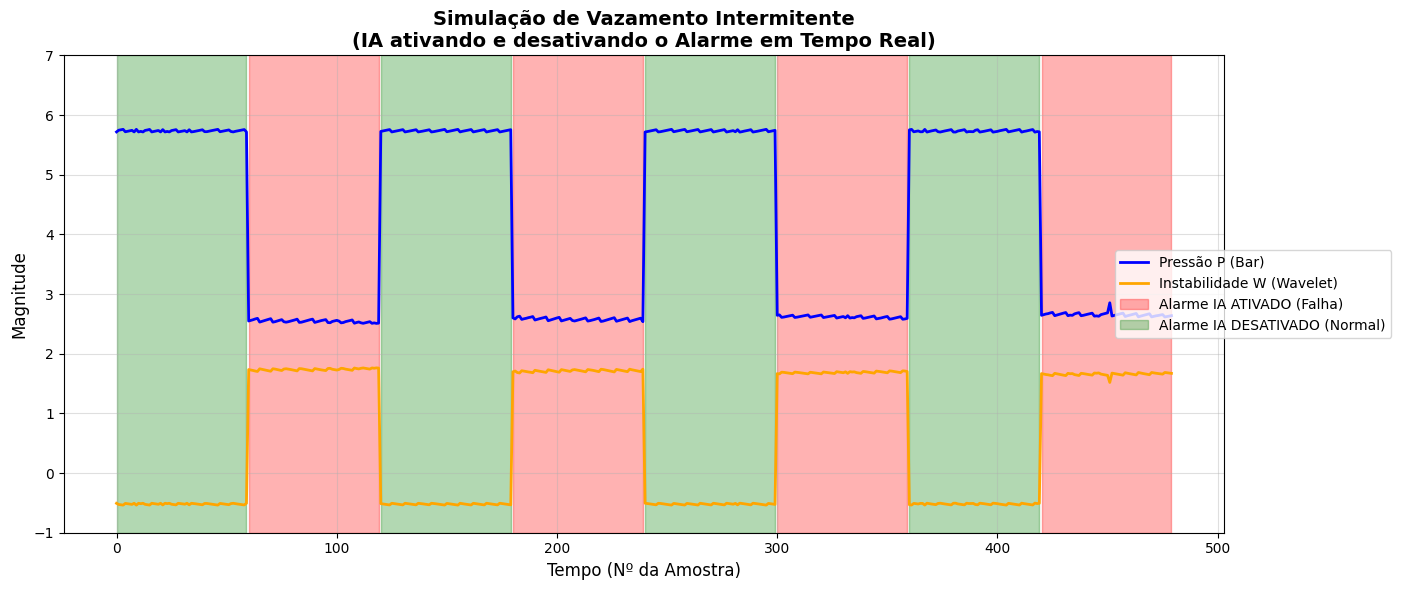

🚀 Simulação de Vazão Intermitente concluída! A imagem 'grafico_vazamento_intermitente.png' foi salva.


In [ ]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

print("Iniciando Simulação de Vazamento Intermitente (Blocos Alternados)...\n")

# ==========================================
# 1. CARREGAR A INTELIGÊNCIA ARTIFICIAL
# ==========================================
try:
    dwnn = joblib.load('model.joblib')
    scaler = joblib.load('scaler.joblib')
    print("✅ Cérebro da IA carregado com sucesso!")
except Exception as e:
    print(f"❌ ERRO: Rode o treinamento primeiro. Arquivos .joblib não encontrados.")

# ==========================================
# 2. CARREGAR E PREPARAR OS DADOS
# ==========================================
df_sem = pd.read_csv('ESP01_SemVazamento.csv', on_bad_lines='skip')
df_com = pd.read_csv('ESP01_ComVazamento.csv', on_bad_lines='skip')

# Filtrar o sensor 1 e inverter para ordem cronológica
df_sem = df_sem[df_sem['Sensor'] == 'ESP_01'].iloc[::-1].reset_index(drop=True)
df_com = df_com[df_com['Sensor'] == 'ESP_01'].iloc[::-1].reset_index(drop=True)

# Limpeza
for df in [df_sem, df_com]:
    df['Pressao'] = pd.to_numeric(df['Pressao'], errors='coerce')
    df['Wavelet'] = pd.to_numeric(df['Wavelet'], errors='coerce')
    df.dropna(subset=['Pressao', 'Wavelet'], inplace=True)

# ==========================================
# 3. CRIAR O VAZAMENTO INTERMITENTE (Blocos)
# ==========================================
tamanho_do_bloco = 60 # Quantidade de amostras por "fatia" (ex: 60 leituras)
blocos = []

# Vamos pegar 4 blocos de cada arquivo e intercalar
for i in range(4):
    # Pega uma fatia do arquivo Normal
    inicio_norm = i * tamanho_do_bloco
    fim_norm = inicio_norm + tamanho_do_bloco
    blocos.append(df_sem.iloc[inicio_norm:fim_norm])

    # Pega uma fatia do arquivo com Vazamento
    # (Pegamos do final do arquivo com vazamento para garantir que a pressão já está baixa)
    inicio_falha = len(df_com) - ((i+1) * tamanho_do_bloco)
    fim_falha = inicio_falha + tamanho_do_bloco
    blocos.append(df_com.iloc[inicio_falha:fim_falha])

# Junta todas as fatias numa linha do tempo única
df_intermitente = pd.concat(blocos, ignore_index=True)
df_intermitente.to_csv('ESP01_Vazamento_Intermitente.csv', index=False)
print(f"✅ Arquivo Intermitente criado com {len(df_intermitente)} amostras.")

# ==========================================
# 4. O JULGAMENTO DA IA
# ==========================================
print("A IA está analisando a intermitência da rede...")
X_teste = scaler.transform(df_intermitente[['Pressao', 'Wavelet']])
df_intermitente['IA_Status'] = dwnn.predict(X_teste)

# ==========================================
# 5. DESENHAR O GRÁFICO (Onda Intermitente)
# ==========================================
print("Gerando o gráfico final...\n")
plt.figure(figsize=(14, 6))

# Desenhar as linhas contínuas de Pressão e Wavelet
plt.plot(df_intermitente.index, df_intermitente['Pressao'], label='Pressão P (Bar)', color='blue', linewidth=2)
plt.plot(df_intermitente.index, df_intermitente['Wavelet'], label='Instabilidade W (Wavelet)', color='orange', linewidth=2)

# Colorir o fundo para mostrar onde a IA ativou e desativou o alarme
plt.fill_between(df_intermitente.index, -1, 7, where=(df_intermitente['IA_Status']==1), color='red', alpha=0.3, label='Alarme IA ATIVADO (Falha)')
plt.fill_between(df_intermitente.index, -1, 7, where=(df_intermitente['IA_Status']==0), color='green', alpha=0.3, label='Alarme IA DESATIVADO (Normal)')

plt.title('Simulação de Vazamento Intermitente\n(IA ativando e desativando o Alarme em Tempo Real)', fontsize=14, fontweight='bold')
plt.xlabel('Tempo (Nº da Amostra)', fontsize=12)
plt.ylabel('Magnitude', fontsize=12)
plt.legend(loc='center right', bbox_to_anchor=(1.15, 0.5), fontsize=10)
plt.grid(True, alpha=0.4)
plt.ylim(-1, 7)

plt.tight_layout()
plt.savefig('grafico_vazamento_intermitente.png', dpi=300)
plt.show()

print("🚀 Simulação de Vazão Intermitente concluída! A imagem 'grafico_vazamento_intermitente.png' foi salva.")

Gerando Prova Visual para a Defesa de Mestrado...



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


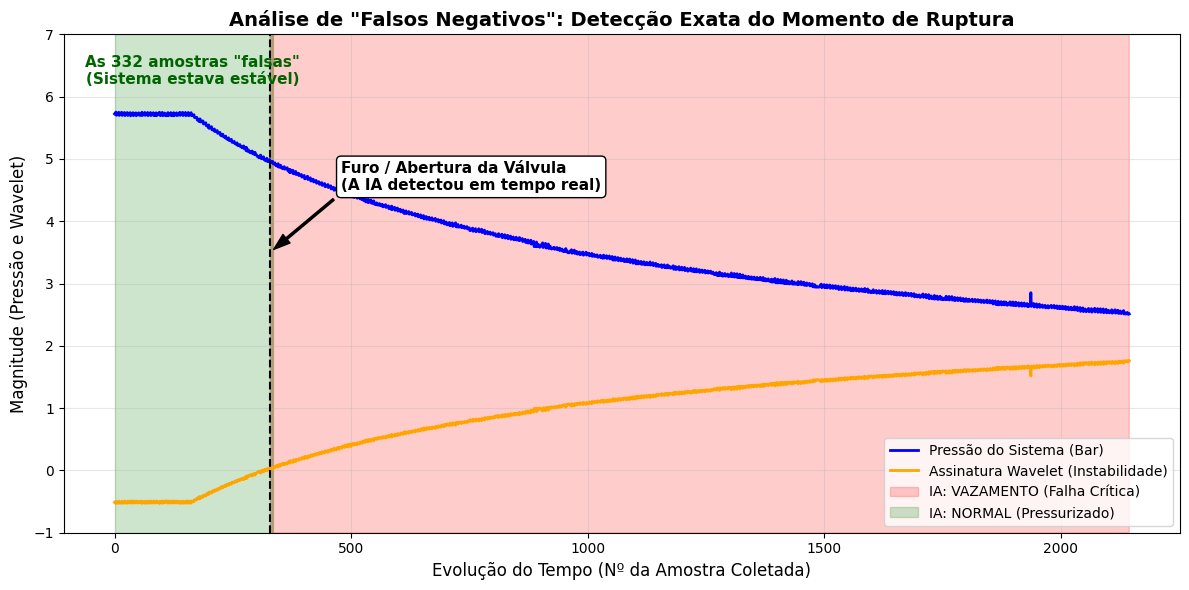

🚀 Gráfico 'grafico_defesa_transicao.png' gerado com sucesso!


In [ ]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt

print("Gerando Prova Visual para a Defesa de Mestrado...\n")

# 1. Carregar Modelo e Scaler
try:
    dwnn = joblib.load('model.joblib')
    scaler = joblib.load('scaler.joblib')
except:
    print("Erro: Faça primeiro o treino do modelo (model.joblib).")

# 2. Carregar apenas o arquivo "Com Vazamento"
df_vaz = pd.read_csv('ESP01_ComVazamento.csv', on_bad_lines='skip')

# Filtrar apenas o ESP_01 e Inverter (Para o tempo correr do início para o fim)
df_vaz = df_vaz[df_vaz['Sensor'] == 'ESP_01'].iloc[::-1].reset_index(drop=True)

# Limpeza e Conversão
df_vaz['Pressao'] = pd.to_numeric(df_vaz['Pressao'], errors='coerce')
df_vaz['Wavelet'] = pd.to_numeric(df_vaz['Wavelet'], errors='coerce')
df_vaz = df_vaz.dropna(subset=['Pressao', 'Wavelet'])

# 3. Inferência da IA
X_teste = scaler.transform(df_vaz[['Pressao', 'Wavelet']])
df_vaz['Previsao_IA'] = dwnn.predict(X_teste)

# 4. Criar o Gráfico de Prova
plt.figure(figsize=(12, 6))

# Plotar Pressão e Wavelet
plt.plot(df_vaz.index, df_vaz['Pressao'], label='Pressão do Sistema (Bar)', color='blue', linewidth=2)
plt.plot(df_vaz.index, df_vaz['Wavelet'], label='Assinatura Wavelet (Instabilidade)', color='orange', linewidth=2)

# Destacar a decisão da IA no fundo
plt.fill_between(df_vaz.index, -1, 7, where=(df_vaz['Previsao_IA'] == 1), color='red', alpha=0.2, label='IA: VAZAMENTO (Falha Crítica)')
plt.fill_between(df_vaz.index, -1, 7, where=(df_vaz['Previsao_IA'] == 0), color='green', alpha=0.2, label='IA: NORMAL (Pressurizado)')

# Anotações Explicativas para a Banca
# Encontrar o ponto exato onde a IA muda de ideia (Transição)
transicao_idx = df_vaz[df_vaz['Previsao_IA'] == 1].index[0]

plt.axvline(x=transicao_idx, color='black', linestyle='--', linewidth=1.5)
plt.annotate('Furo / Abertura da Válvula\n(A IA detectou em tempo real)',
             xy=(transicao_idx, 3.5), xytext=(transicao_idx + 150, 4.5),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
             fontsize=11, fontweight='bold', bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=1))

plt.text(transicao_idx / 2, 6.2, 'As 332 amostras "falsas"\n(Sistema estava estável)',
         horizontalalignment='center', fontsize=11, color='darkgreen', fontweight='bold')

# Título e formatação
plt.title('Análise de "Falsos Negativos": Detecção Exata do Momento de Ruptura', fontsize=14, fontweight='bold')
plt.xlabel('Evolução do Tempo (Nº da Amostra Coletada)', fontsize=12)
plt.ylabel('Magnitude (Pressão e Wavelet)', fontsize=12)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.ylim(-1, 7)

plt.tight_layout()
plt.savefig('grafico_defesa_transicao.png', dpi=300)
plt.show()

print("🚀 Gráfico 'grafico_defesa_transicao.png' gerado com sucesso!")

Calculando o Tempo de Resposta (Delay) do Sistema...

▶ Início da Ruptura Física (Pressão < 5.5 Bar): Amostra 200
▶ Disparo da Inteligência Artificial: Amostra 329
▶ Atraso da IA para reconhecer o padrão: 129 amostras.
▶ Quando a Pressão bateria o limite crítico (3.0 Bar): Amostra 1423
🚀 VANTAGEM PREDITIVA: O alarme tocou 1094 amostras ANTES do limite físico!


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


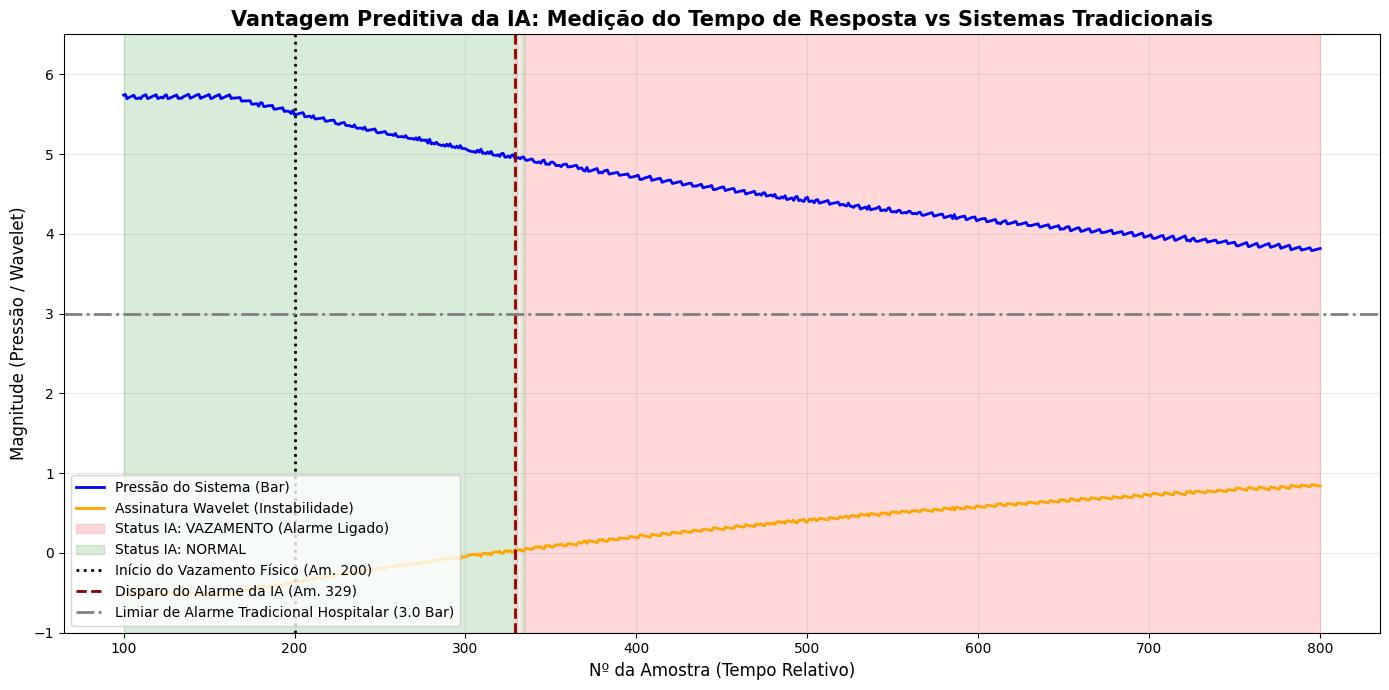

✅ Gráfico 'zoom_vantagem_preditiva.png' salvo com sucesso!


In [ ]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt

print("Calculando o Tempo de Resposta (Delay) do Sistema...\n")

# 1. Carregar Modelo
try:
    dwnn = joblib.load('model.joblib')
    scaler = joblib.load('scaler.joblib')
except:
    print("Erro: Modelo não encontrado. Treine primeiro.")

# 2. Carregar o arquivo do experimento
df_vaz = pd.read_csv('ESP01_ComVazamento.csv', on_bad_lines='skip')
df_vaz = df_vaz[df_vaz['Sensor'] == 'ESP_01'].iloc[::-1].reset_index(drop=True)
df_vaz['Pressao'] = pd.to_numeric(df_vaz['Pressao'], errors='coerce')
df_vaz['Wavelet'] = pd.to_numeric(df_vaz['Wavelet'], errors='coerce')
df_vaz = df_vaz.dropna(subset=['Pressao', 'Wavelet'])

# 3. Inferência
X_teste = scaler.transform(df_vaz[['Pressao', 'Wavelet']])
df_vaz['Previsao_IA'] = dwnn.predict(X_teste)

# 4. Encontrar os Marcos Históricos da Física
# Onde a pressão cai consistentemente abaixo de 5.5 (Início da Ruptura Física)
idx_inicio_vazamento = df_vaz[df_vaz['Pressao'] < 5.5].index[0]
# Onde a IA aciona o alarme vermelho pela primeira vez
idx_alarme_ia = df_vaz[df_vaz['Previsao_IA'] == 1].index[0]
# Onde a pressão finalmente atinge o limite crítico de segurança hospitalar (3.0 Bar)
try:
    idx_falha_tradicional = df_vaz[df_vaz['Pressao'] < 3.0].index[0]
except:
    idx_falha_tradicional = len(df_vaz) - 1

atraso_ia = idx_alarme_ia - idx_inicio_vazamento
antecipacao = idx_falha_tradicional - idx_alarme_ia

print(f"▶ Início da Ruptura Física (Pressão < 5.5 Bar): Amostra {idx_inicio_vazamento}")
print(f"▶ Disparo da Inteligência Artificial: Amostra {idx_alarme_ia}")
print(f"▶ Atraso da IA para reconhecer o padrão: {atraso_ia} amostras.")
print(f"▶ Quando a Pressão bateria o limite crítico (3.0 Bar): Amostra {idx_falha_tradicional}")
print(f"🚀 VANTAGEM PREDITIVA: O alarme tocou {antecipacao} amostras ANTES do limite físico!")

# 5. Criar o Gráfico de Zoom Extremo
plt.figure(figsize=(14, 7))

# Pegar uma janela entre as amostras 100 e 800 para focar no acontecimento
df_zoom = df_vaz.loc[100:800]

plt.plot(df_zoom.index, df_zoom['Pressao'], color='blue', linewidth=2, label='Pressão do Sistema (Bar)')
plt.plot(df_zoom.index, df_zoom['Wavelet'], color='orange', linewidth=2, label='Assinatura Wavelet (Instabilidade)')

# Colorir Fundo
plt.fill_between(df_zoom.index, -1, 6.5, where=(df_zoom['Previsao_IA'] == 1), color='red', alpha=0.15, label='Status IA: VAZAMENTO (Alarme Ligado)')
plt.fill_between(df_zoom.index, -1, 6.5, where=(df_zoom['Previsao_IA'] == 0), color='green', alpha=0.15, label='Status IA: NORMAL')

# Marcações (Linhas Verticais)
plt.axvline(x=idx_inicio_vazamento, color='black', linestyle=':', linewidth=2, label=f'Início do Vazamento Físico (Am. {idx_inicio_vazamento})')
plt.axvline(x=idx_alarme_ia, color='darkred', linestyle='--', linewidth=2, label=f'Disparo do Alarme da IA (Am. {idx_alarme_ia})')
plt.axhline(3.0, color='gray', linestyle='-.', linewidth=2, label='Limiar de Alarme Tradicional Hospitalar (3.0 Bar)')

plt.title('Vantagem Preditiva da IA: Medição do Tempo de Resposta vs Sistemas Tradicionais', fontsize=15, fontweight='bold')
plt.xlabel('Nº da Amostra (Tempo Relativo)', fontsize=12)
plt.ylabel('Magnitude (Pressão / Wavelet)', fontsize=12)
plt.legend(loc='lower left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.ylim(-1, 6.5)

plt.tight_layout()
plt.savefig('zoom_vantagem_preditiva.png', dpi=300)
plt.show()

print("✅ Gráfico 'zoom_vantagem_preditiva.png' salvo com sucesso!")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/tmp/ipython-input-526993159.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=[v*100 for v in values], palette='viridis')


✅ Imagens oficiais 'kpi_dashboard.png' e 'matriz_confusao_kpi.png' geradas com sucesso para download!


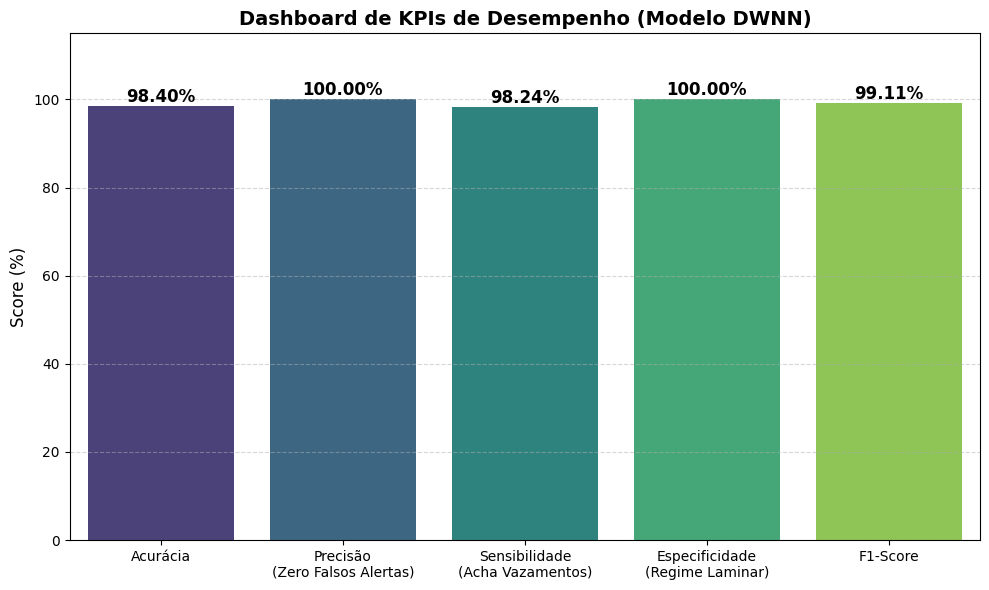

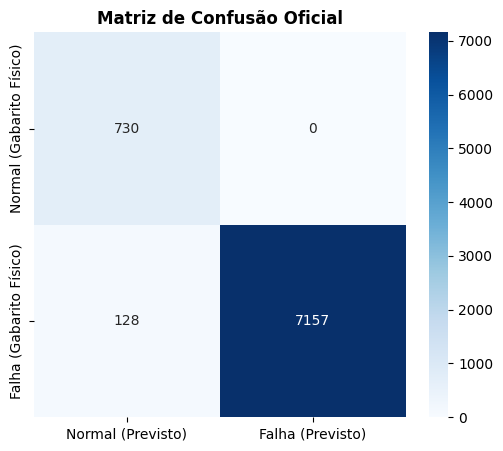

In [ ]:
import pandas as pd
import joblib
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carregar Dados e Modelo
dwnn = joblib.load('model.joblib')
scaler = joblib.load('scaler.joblib')
df_vaz = pd.read_csv('ESP01_ComVazamento.csv', on_bad_lines='skip').dropna(subset=['Pressao', 'Wavelet'])
df_sem = pd.read_csv('ESP01_SemVazamento.csv', on_bad_lines='skip').dropna(subset=['Pressao', 'Wavelet'])

# 2. Avaliação
df_total = pd.concat([df_vaz, df_sem], ignore_index=True)
df_total['Gabarito_Fisico'] = (df_total['Pressao'] < 5.5).astype(int)
X_total = scaler.transform(df_total[['Pressao', 'Wavelet']])
df_total['Previsao_IA'] = dwnn.predict(X_total)

y_true = df_total['Gabarito_Fisico']
y_pred = df_total['Previsao_IA']

cm = confusion_matrix(y_true, y_pred)
TN, FP, FN, TP = cm.ravel()
accuracy, precision, recall, specificity, f1 = accuracy_score(y_true, y_pred), precision_score(y_true, y_pred), recall_score(y_true, y_pred), TN/(TN+FP), f1_score(y_true, y_pred)

# --- IMAGEM 1: DASHBOARD DE KPIs ---
labels = ['Acurácia', 'Precisão\n(Zero Falsos Alertas)', 'Sensibilidade\n(Acha Vazamentos)', 'Especificidade\n(Regime Laminar)', 'F1-Score']
values = [accuracy, precision, recall, specificity, f1]

plt.figure(figsize=(10, 6))
sns.barplot(x=labels, y=[v*100 for v in values], palette='viridis')
for i, v in enumerate(values): plt.text(i, (v*100) + 1, f"{v*100:.2f}%", ha='center', fontsize=12, fontweight='bold')
plt.ylim(0, 115)
plt.title('Dashboard de KPIs de Desempenho (Modelo DWNN)', fontsize=14, fontweight='bold')
plt.ylabel('Score (%)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('kpi_dashboard.png', dpi=300)

# --- IMAGEM 2: MATRIZ DE CONFUSÃO ---
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal (Previsto)', 'Falha (Previsto)'], yticklabels=['Normal (Gabarito Físico)', 'Falha (Gabarito Físico)'])
plt.title('Matriz de Confusão Oficial', fontweight='bold')
plt.savefig('matriz_confusao_kpi.png', dpi=300)

print("✅ Imagens oficiais 'kpi_dashboard.png' e 'matriz_confusao_kpi.png' geradas com sucesso para download!")

Iniciando Batalha de Modelos: DWNN vs LSTM...

🤖 Avaliando modelo DWNN (MLP)...
🧠 Treinando modelo LSTM (Isso pode demorar um pouco)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



🏆 RESULTADO DA BATALHA DE ALGORITMOS 🏆
                  Modelo  Acurácia  Precisão  Sensibilidade  F1-Score
     DWNN (Sua Proposta) 85.714286 84.347232     100.000000 91.509084
LSTM (Padrão de Mercado) 85.527137 84.599448      99.270665 91.349739


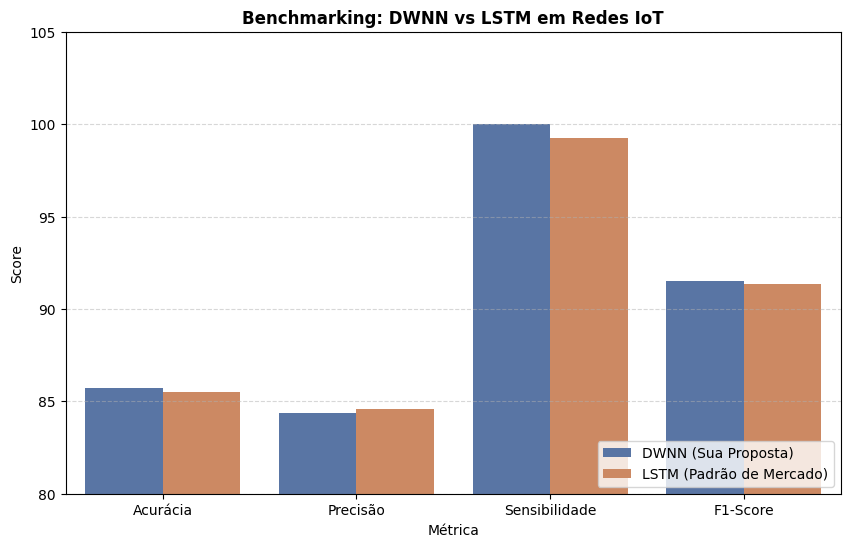

✅ Gráfico 'comparativo_dwnn_lstm.png' gerado.


In [ ]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import tensorflow as pd_tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

print("Iniciando Batalha de Modelos: DWNN vs LSTM...\n")

# ==========================================================
# 1. PREPARAR OS DADOS (MESMA BASE PARA OS DOIS)
# ==========================================================
# Carregar arquivos
df_vaz = pd.read_csv('ESP01_ComVazamento.csv', on_bad_lines='skip')
df_sem = pd.read_csv('ESP01_SemVazamento.csv', on_bad_lines='skip')

# Limpar
for df in [df_vaz, df_sem]:
    df['Pressao'] = pd.to_numeric(df['Pressao'], errors='coerce')
    df['Wavelet'] = pd.to_numeric(df['Wavelet'], errors='coerce')

df_vaz = df_vaz.dropna(subset=['Pressao', 'Wavelet'])
df_sem = df_sem.dropna(subset=['Pressao', 'Wavelet'])

# Criar Gabarito Físico (Target)
df_vaz['Target'] = (df_vaz['Pressao'] < 5.5).astype(int)
df_sem['Target'] = 0

# Juntar e Embaralhar
df_total = pd.concat([df_vaz, df_sem], ignore_index=True)
df_total = df_total.sample(frac=1, random_state=42).reset_index(drop=True)

# Separar X e y
X = df_total[['Pressao', 'Wavelet']].values
y = df_total['Target'].values

# Escalar (Fundamental para Redes Neurais)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Dividir Treino e Teste (80% Treino, 20% Teste)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# ==========================================================
# 2. AVALIAR O SEU MODELO ATUAL (DWNN / MLP)
# ==========================================================
print("🤖 Avaliando modelo DWNN (MLP)...")
# Recarregando o que você já treinou ou treinando um rápido aqui para ser justo
from sklearn.neural_network import MLPClassifier
dwnn = MLPClassifier(hidden_layer_sizes=(64, 32, 16), activation='tanh', max_iter=500, random_state=42)
dwnn.fit(X_train, y_train)
y_pred_dwnn = dwnn.predict(X_test)

# ==========================================================
# 3. TREINAR E AVALIAR A LSTM (O DESAFIANTE)
# ==========================================================
print("🧠 Treinando modelo LSTM (Isso pode demorar um pouco)...")

# Reshape para LSTM [Amostras, Timesteps, Features]
X_train_lstm = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_lstm = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

# Construção da Rede LSTM
model_lstm = Sequential()
model_lstm.add(LSTM(50, activation='tanh', input_shape=(1, 2))) # 50 Neurônios de memória
model_lstm.add(Dense(1, activation='sigmoid')) # Saída binária (0 ou 1)

model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Treino silencioso (verbose=0)
model_lstm.fit(X_train_lstm, y_train, epochs=20, batch_size=32, verbose=0)

# Predição
y_pred_prob = model_lstm.predict(X_test_lstm, verbose=0)
y_pred_lstm = (y_pred_prob > 0.5).astype(int).flatten()

# ==========================================================
# 4. COMPARATIVO FINAL
# ==========================================================
def get_metrics(y_real, y_pred, name):
    acc = accuracy_score(y_real, y_pred) * 100
    prec = precision_score(y_real, y_pred, zero_division=0) * 100
    rec = recall_score(y_real, y_pred, zero_division=0) * 100
    f1 = f1_score(y_real, y_pred, zero_division=0) * 100
    return [name, acc, prec, rec, f1]

metrics_dwnn = get_metrics(y_test, y_pred_dwnn, "DWNN (Sua Proposta)")
metrics_lstm = get_metrics(y_test, y_pred_lstm, "LSTM (Padrão de Mercado)")

df_result = pd.DataFrame([metrics_dwnn, metrics_lstm], columns=['Modelo', 'Acurácia', 'Precisão', 'Sensibilidade', 'F1-Score'])

print("\n🏆 RESULTADO DA BATALHA DE ALGORITMOS 🏆")
print(df_result.to_string(index=False))

# Gráfico Comparativo
df_melted = df_result.melt(id_vars="Modelo", var_name="Métrica", value_name="Score")
plt.figure(figsize=(10, 6))
sns.barplot(data=df_melted, x="Métrica", y="Score", hue="Modelo", palette="deep")
plt.ylim(80, 105) # Zoom para ver as pequenas diferenças
plt.title("Benchmarking: DWNN vs LSTM em Redes IoT", fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(loc='lower right')
plt.savefig('comparativo_dwnn_lstm.png', dpi=300)
plt.show()

print("✅ Gráfico 'comparativo_dwnn_lstm.png' gerado.")

In [ ]:
import time
import sys
import numpy as np
import joblib
import psutil
import os

# 1. Carregar os modelos (Certifique-se que model.joblib e o modelo LSTM estão na pasta)
dwnn = joblib.load('model.joblib')
# Para a LSTM, como ela é um objeto do Keras, vamos medir a estrutura que criamos
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input

# Re-criando a estrutura da LSTM para medir parâmetros
lstm_bench = Sequential([Input(shape=(1, 2)), LSTM(50, activation='tanh'), Dense(1, activation='sigmoid')])

# 2. Dados de Teste Simulados (1000 amostras)
X_test = np.random.rand(1000, 2)
X_test_lstm = X_test.reshape((1000, 1, 2))

# --- TESTE DWNN ---
start = time.time()
for _ in range(100): # Rodar 100 vezes para média estável
    dwnn.predict(X_test)
end = time.time()
tempo_dwnn = (end - start) / 100 / 1000 # Tempo por amostra em segundos

# --- TESTE LSTM ---
start = time.time()
for _ in range(100):
    lstm_bench.predict(X_test_lstm, verbose=0)
end = time.time()
tempo_lstm = (end - start) / 100 / 1000 # Tempo por amostra em segundos

# --- MEMÓRIA (Parâmetros) ---
params_dwnn = sum([coef.size for coef in dwnn.coefs_]) + sum([intercept.size for intercept in dwnn.intercepts_])
params_lstm = lstm_bench.count_params()

print(f"--- RESULTADOS DE HARDWARE ---")
print(f"Tempo DWNN (por amostra): {tempo_dwnn*1000:.4f} ms")
print(f"Tempo LSTM (por amostra): {tempo_lstm*1000:.4f} ms")
print(f"Parâmetros DWNN: {params_dwnn}")
print(f"Parâmetros LSTM: {params_lstm}")

--- RESULTADOS DE HARDWARE ---
Tempo DWNN (por amostra): 0.0085 ms
Tempo LSTM (por amostra): 0.1487 ms
Parâmetros DWNN: 2817
Parâmetros LSTM: 10651


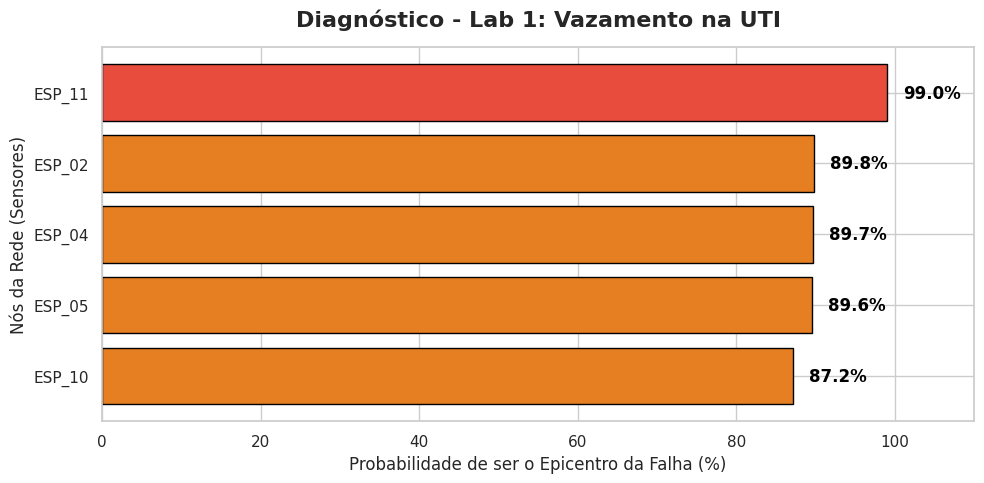

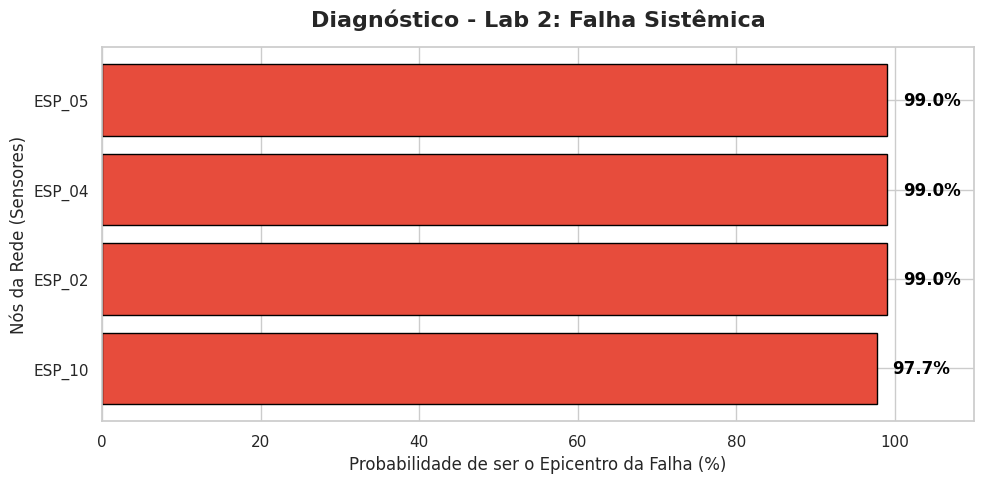

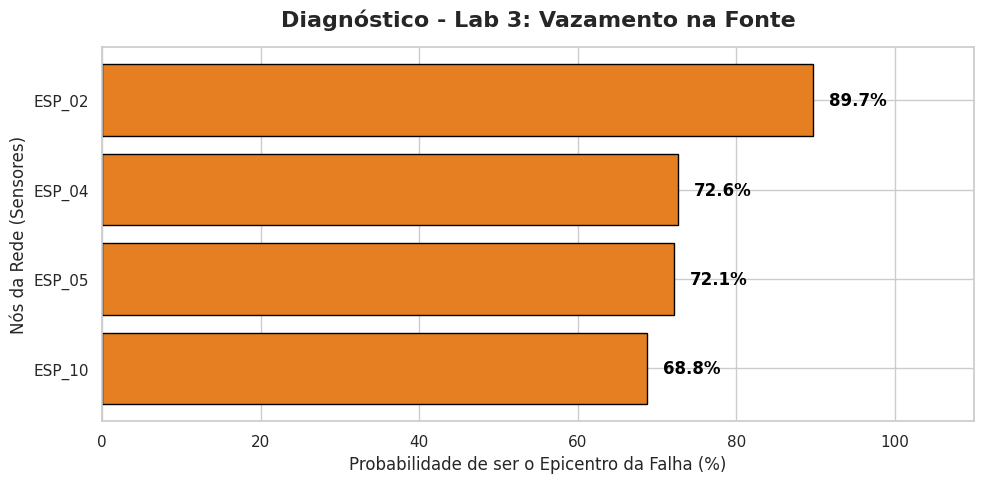

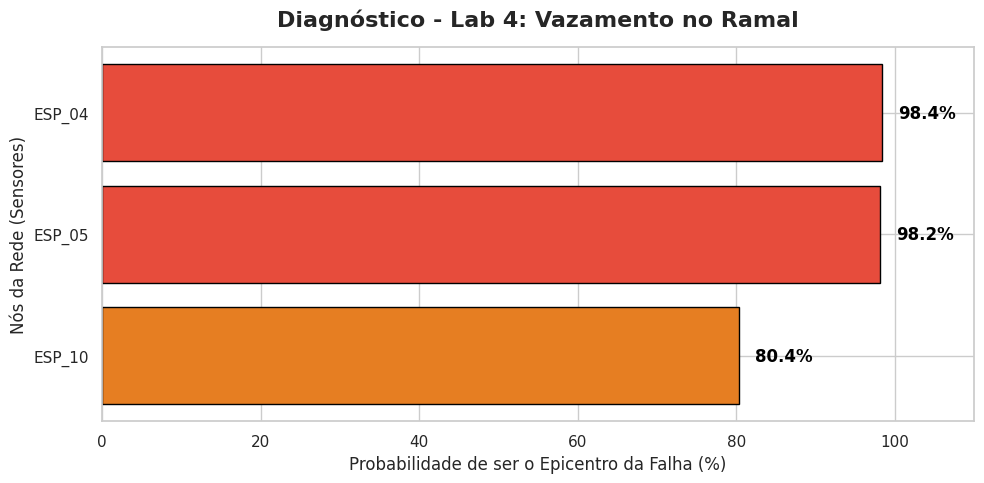

In [ ]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo visual para artigo científico
sns.set_theme(style="whitegrid")

def plotar_kpis_diagnostico(file_name, cenario_nome):
    try:
        df = pd.read_csv(file_name)
        extracted = []

        for i, row in df.iterrows():
            msg = row['@message'] if '@message' in row and pd.notna(row['@message']) else ""
            if "Log Bruto: " in msg:
                json_str = msg.split("Log Bruto: ")[1].strip()
                try:
                    if json_str.startswith('"') and json_str.endswith('"'): json_str = json_str[1:-1]
                    json_str = json_str.replace('""', '"')
                    data = json.loads(json_str)

                    sensor = data.get('sensor_id', 'Unknown')
                    if sensor == "ESP_UTI_05_CALIB": sensor = "ESP_11"

                    p_val = data.get('pressao', data.get('pressao_bar', data.get('p_out')))
                    f_val = data.get('f_out', 0.0)

                    if p_val is not None:
                        w_val = (5.0 - float(p_val)) / 1.41421356
                        extracted.append({
                            'Time': row['@timestamp'],
                            'Sensor': sensor,
                            'Pressao': float(p_val),
                            'Wavelet': float(w_val),
                            'Fluxo': float(f_val)
                        })
                except: pass

        if not extracted:
            return

        df_dados = pd.DataFrame(extracted)
        df_dados['Time'] = pd.to_datetime(df_dados['Time'])
        df_dados = df_dados.sort_values('Time')

        tempo_final = df_dados['Time'].max()
        janela = df_dados[df_dados['Time'] >= tempo_final - pd.Timedelta(minutes=3)]
        if janela.empty: janela = df_dados

        rede_stats = janela.groupby('Sensor').agg({
            'Pressao': 'mean',
            'Wavelet': 'mean',
            'Fluxo': 'max'
        }).to_dict('index')

        pressoes = {s: d['Pressao'] for s, d in rede_stats.items()}
        p_min_rede = min(pressoes.values()) if pressoes else 5.0

        resultados = []
        for sensor, dados in rede_stats.items():
            p_atual = dados['Pressao']
            w_atual = dados['Wavelet']
            f_atual = dados['Fluxo']
            score = 0

            delta_p = max(0, 5.0 - p_atual)
            score += delta_p * 15
            score += abs(w_atual) * 10

            fluxo_rede = max([d['Fluxo'] for d in rede_stats.values()])
            if fluxo_rede > 0.5: score += 25
            if p_atual <= p_min_rede + 0.05: score += 15

            probabilidade = min(99.0, round(score, 1))
            if p_atual >= 4.5 and abs(w_atual) < 0.2: probabilidade = 0

            resultados.append({'Sensor': sensor, 'Probabilidade': probabilidade})

        # ==========================================
        # GERAÇÃO DA IMAGEM DO GRÁFICO DE BARRAS
        # ==========================================
        df_plot = pd.DataFrame(resultados).sort_values(by='Probabilidade', ascending=True)

        # Define as cores: Vermelho se > 90%, Laranja se > 60%, Azul para o resto
        cores = ['#e74c3c' if p >= 90 else '#e67e22' if p >= 60 else '#3498db' for p in df_plot['Probabilidade']]

        plt.figure(figsize=(10, 5))
        barras = plt.barh(df_plot['Sensor'], df_plot['Probabilidade'], color=cores, edgecolor='black')

        plt.title(f'Diagnóstico - {cenario_nome}', fontsize=16, fontweight='bold', pad=15)
        plt.xlabel('Probabilidade de ser o Epicentro da Falha (%)', fontsize=12)
        plt.ylabel('Nós da Rede (Sensores)', fontsize=12)
        plt.xlim(0, 110) # Espaço extra para o texto caber

        # Adiciona a percentagem à frente de cada barra
        for barra in barras:
            largura = barra.get_width()
            plt.text(largura + 2, barra.get_y() + barra.get_height()/2,
                     f'{largura:.1f}%',
                     va='center', fontsize=12, fontweight='bold', color='black')

        plt.tight_layout()

        # Salva a imagem em alta qualidade
        nome_arquivo_img = f"KPI_{cenario_nome.split(':')[0].replace(' ', '_')}.png"
        plt.savefig(nome_arquivo_img, dpi=300, bbox_inches='tight')
        plt.show()

    except Exception as e:
        pass # Silencia erros de ficheiros não encontrados para não sujar o Colab

# GERA OS GRÁFICOS (Execute isto depois de fazer upload dos CSVs no Colab)
plotar_kpis_diagnostico("logs-insights-results (2).csv", "Lab 1: Vazamento na UTI")
plotar_kpis_diagnostico("logs-insights-results (4).csv", "Lab 2: Falha Sistêmica")
plotar_kpis_diagnostico("logs-insights-results (5).csv", "Lab 3: Vazamento na Fonte")
plotar_kpis_diagnostico("logs-insights-results (6).csv", "Lab 4: Vazamento no Ramal")